In [1]:
!date

Thu Jun 11 15:18:17 PDT 2026


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pysam
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm
from scipy.stats import pearsonr
import os

In [3]:
projdir       = '/u/project/cluo/terencew/claude/demux/pool_design'
srcdir        = '/u/project/cluo/terencew/demux_benchmark/pool_design'
figdir        = f'{projdir}/figures'
bcf_path      = '/u/project/cluo/IGVF_Share/genotypes/IGVF50/vcf_joint/snp_filt2_demux.bcf'
pool_meta_path = '/u/project/cluo/IGVF_Share/studydesign/demux_10x/202600203_fixeddemuxschema_pooldetails.tsv'

In [4]:
pool_meta = pd.read_csv(pool_meta_path, sep='\t')
pool_meta.shape

(469, 4)

In [5]:
pool_meta.head()

,pool,run,line,time
0,A2,IGVF50GEXA2,C1,NaN
1,A2,IGVF50GEXA2,C12,7
2,A2,IGVF50GEXA2,C13,0
3,A2,IGVF50GEXA2,C20,16
4,A2,IGVF50GEXA2,C26,5


In [6]:
### load dosage matrix from BCF (parallel by chromosome)
# dosage: 0/0 -> 0, 0/1 -> 1, 1/1 -> 2, missing -> NaN
def process_chrom(chrom):
    bcf = pysam.VariantFile(bcf_path)
    samples = list(bcf.header.samples)
    records, variant_ids = [], []
    for rec in bcf.fetch(chrom):
        dosages = []
        for s in samples:
            gt = rec.samples[s]['GT']
            dosages.append(np.nan if None in gt else sum(gt))
        records.append(dosages)
        variant_ids.append(f"{rec.chrom}_{rec.pos}_{rec.ref}_{rec.alts[0]}")
    return pd.DataFrame(records, index=variant_ids, columns=samples)

chroms = [f'chr{i}' for i in range(1, 23)]
with ProcessPoolExecutor(max_workers=22) as executor:
    results = list(tqdm(executor.map(process_chrom, chroms), total=len(chroms)))

dosage_df = pd.concat(results)
print(dosage_df.shape)

100%|██████████| 22/22 [01:23<00:00,  3.80s/it]


(17319568, 49)


In [7]:
dosage_df.head()

,A1,A2,A3,A4,A6,A7,A8,A9,A10,A11,...,C32,C33,C34,C35,C36,C37,C38,C39,L2,V3
chr1_29443_A_G,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
chr1_29571_G_C,1,1,1,1,1,1,1,1,1,0,...,1,2,1,1,1,1,1,1,1,1
chr1_98933_T_A,0,0,0,2,0,0,1,0,0,0,...,0,0,2,0,0,0,0,0,0,0
chr1_98945_C_T,0,0,0,2,0,0,2,0,0,2,...,1,0,2,1,0,0,0,0,0,2
chr1_99103_T_C,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
### Bernoulli KL divergence between donor genotype emission distributions
# For donor i at a SNP with dosage d: P(alt read | g_i) = geno_p[d]
# Expected per-SNP LL-gap from donor i's perspective vs donor j:
#   E[log P(read|g_i) - log P(read|g_j)] = KL(Bernoulli(p_i) || Bernoulli(p_j))
#   = p_i*log(p_i/p_j) + (1-p_i)*log((1-p_i)/(1-p_j))
eps = 0.01
geno_p = np.array([eps, 0.5, 1.0 - eps])  # dosage 0, 1, 2

samples = pool_meta['run'].unique()
print(f'{len(samples)} pools')

63 pools


In [9]:
def get_pool_kl(s):
    tmp_donors = pool_meta[pool_meta['run'] == s]['line'].values
    G = dosage_df[tmp_donors].dropna().values.astype(int)  # (n_snps, n_donors)
    p = geno_p[G]  # (n_snps, n_donors): emission probability for each donor at each SNP

    n_snps, n_donors = p.shape
    kl_sum = np.zeros((n_donors, n_donors))
    chunk = 200_000
    for start in range(0, n_snps, chunk):
        pi = p[start:start+chunk, :, np.newaxis]  # (c, n_donors, 1)
        pj = p[start:start+chunk, np.newaxis, :]  # (c, 1, n_donors)
        kl_sum += (pi * np.log(pi / pj) + (1 - pi) * np.log((1 - pi) / (1 - pj))).sum(axis=0)
    kl_mat = kl_sum / n_snps

    # symmetrize (KL is asymmetric; take mean of both directions)
    kl_sym = (kl_mat + kl_mat.T) / 2
    np.fill_diagonal(kl_sym, np.inf)
    nn_kl = kl_sym.min(axis=1)  # nearest-neighbor KL per donor

    upper = kl_sym[np.triu_indices(n_donors, k=1)]
    return {
        'sample':   s,
        'donors':   tmp_donors.tolist(),
        'mean_kl':  float(upper.mean()),
        'min_kl':   float(nn_kl.min()),
        'nn_kl':    nn_kl.tolist(),
        'n_snps':   n_snps,
    }

with ProcessPoolExecutor(max_workers=22) as executor:
    pool_results = list(tqdm(executor.map(get_pool_kl, samples), total=len(samples)))

100%|██████████| 63/63 [08:19<00:00,  7.93s/it]


In [10]:
### per-pool KL summary
kl_df = pd.DataFrame([{'sample': r['sample'], 'mean_kl': r['mean_kl'],
                        'min_kl': r['min_kl'], 'n_snps': r['n_snps']}
                       for r in pool_results]).set_index('sample')
kl_df.head()

,mean_kl,min_kl,n_snps
sample,,,
IGVF50GEXA2,0.371834,0.280559,17319568
IGVF50GEXA3,0.353434,0.281141,17319568
IGVF50GEXA4,0.378239,0.362069,17319568
IGVF50GEXA5,0.361051,0.281047,17319568
IGVF50GEXB1,0.364901,0.275389,17319568


In [11]:
kl_df.shape

(63, 3)

In [12]:
### per-donor nearest-neighbor KL (long format)
donor_rows = []
for r in pool_results:
    for donor, nn in zip(r['donors'], r['nn_kl']):
        donor_rows.append({'sample': r['sample'], 'donor': donor, 'nn_kl': nn})
donor_kl_df = pd.DataFrame(donor_rows)
donor_kl_df.head()

,sample,donor,nn_kl
0,IGVF50GEXA2,C1,0.366685
1,IGVF50GEXA2,C12,0.373257
2,IGVF50GEXA2,C13,0.366685
3,IGVF50GEXA2,C20,0.280559
4,IGVF50GEXA2,C26,0.372957


In [13]:
os.makedirs(f'{srcdir}/csv/50_line', exist_ok=True)
kl_df.to_csv(f'{srcdir}/csv/50_line/pool_expected_kl.csv', sep='\t')
donor_kl_df.to_csv(f'{srcdir}/csv/50_line/donor_nn_kl.csv', sep='\t', index=False)
print('saved pool_expected_kl.csv and donor_nn_kl.csv')

saved pool_expected_kl.csv and donor_nn_kl.csv


In [14]:
### load geometric distance and ancestry for comparison
dists = pd.read_csv(f'{srcdir}/csv/50_line/pool_genetic_dists.csv', sep='\t', index_col=0)
dists = dists.set_index('sample')
eth = pd.read_csv(f'{srcdir}/csv/50_line/pool_ancestries.csv', sep='\t', index_col=0)
eth.index = eth['sample']
eth['n_eur'] = (eth['eur_prop'] * 6).round().astype(int)

In [15]:
### load observed per-SNP LL-gap from 01g
persnp = pd.read_csv(f'{srcdir}/csv/50_line/pool_persnp_ll.csv', sep='\t', index_col=0)
persnp.head()

,n_singlets,mean_snps,mean_ll_gap,p05_ll_gap,mean_norm_gap,p05_norm_gap
sample,,,,,,
IGVF50GEXA2,7701,2071.045968,148.430741,16.7900,0.067321,0.022743
IGVF50GEXA3,6647,1547.516323,109.562285,2.9530,0.064057,0.008156
IGVF50GEXA4,5452,3163.256603,247.786524,22.9185,0.076474,0.028343
IGVF50GEXA5,11511,1276.643037,90.896470,7.9450,0.068073,0.017616
IGVF50GEXB1,13447,1258.349372,98.367797,12.5630,0.074919,0.033101


In [16]:
plot_df = kl_df.join(dists[['mean', 'min']]).join(eth[['n_eur']]).join(persnp[['mean_norm_gap', 'p05_norm_gap', 'mean_snps']])
plot_df.head()

,mean_kl,min_kl,n_snps,mean,min,n_eur,mean_norm_gap,p05_norm_gap,mean_snps
sample,,,,,,,,,
IGVF50GEXA2,0.371834,0.280559,17319568,2388.348519,2077.537966,3,0.067321,0.022743,2071.045968
IGVF50GEXA3,0.353434,0.281141,17319568,2326.796765,2079.691804,3,0.064057,0.008156,1547.516323
IGVF50GEXA4,0.378239,0.362069,17319568,2411.676665,2360.111650,1,0.076474,0.028343,3163.256603
IGVF50GEXA5,0.361051,0.281047,17319568,2352.908268,2079.346051,3,0.068073,0.017616,1276.643037
IGVF50GEXB1,0.364901,0.275389,17319568,2363.499763,2058.309501,3,0.074919,0.033101,1258.349372


In [17]:
### pearson correlations: expected KL vs observed and vs Euclidean distance
print('Expected KL vs observed per-SNP LL-gap:')
for kl_col in ['mean_kl', 'min_kl']:
    for obs_col in ['mean_norm_gap', 'p05_norm_gap']:
        sub = plot_df[[kl_col, obs_col]].dropna()
        r, p = pearsonr(sub[kl_col], sub[obs_col])
        print(f'  {kl_col:10s} vs {obs_col:18s}: r={r:+.3f}  p={p:.3f}')

print('\nExpected KL vs Euclidean genetic distance:')
for kl_col in ['mean_kl', 'min_kl']:
    for dist_col in ['min', 'mean']:
        sub = plot_df[[kl_col, dist_col]].dropna()
        r, p = pearsonr(sub[kl_col], sub[dist_col])
        print(f'  {kl_col:10s} vs {dist_col:5s} dist: r={r:+.3f}  p={p:.3f}')

Expected KL vs observed per-SNP LL-gap:
  mean_kl    vs mean_norm_gap     : r=+0.128  p=0.319
  mean_kl    vs p05_norm_gap      : r=+0.002  p=0.988
  min_kl     vs mean_norm_gap     : r=+0.399  p=0.001
  min_kl     vs p05_norm_gap      : r=+0.289  p=0.021

Expected KL vs Euclidean genetic distance:
  mean_kl    vs min   dist: r=+0.136  p=0.286
  mean_kl    vs mean  dist: r=+1.000  p=0.000
  min_kl     vs min   dist: r=+0.998  p=0.000
  min_kl     vs mean  dist: r=+0.150  p=0.239


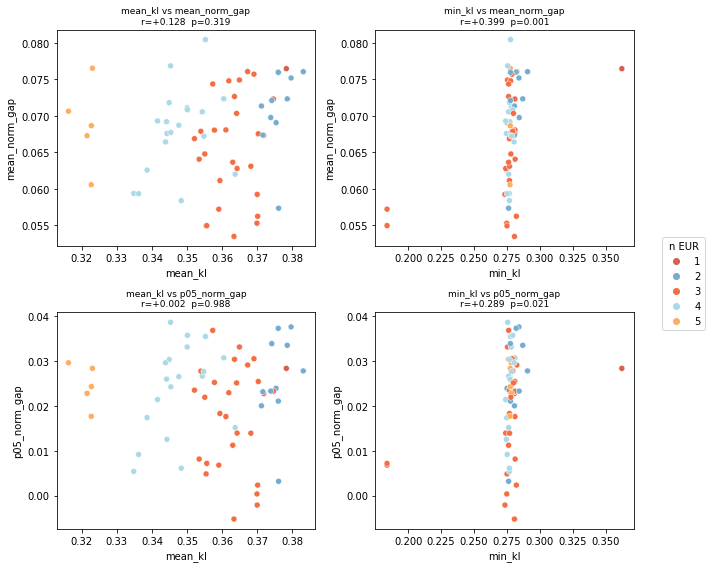

In [18]:
### scatter: expected KL vs observed per-SNP LL-gap
pal = {0: '#4393c3', 1: '#d6604d', 2: '#74add1', 3: '#f46d43',
       4: '#abd9e9', 5: '#fdae61', 6: '#e0f3f8'}

fig, axes = plt.subplots(2, 2, figsize=(9, 8))
pairs = [('mean_kl', 'mean_norm_gap'), ('min_kl', 'mean_norm_gap'),
         ('mean_kl', 'p05_norm_gap'),  ('min_kl', 'p05_norm_gap')]
for ax, (kc, oc) in zip(axes.flat, pairs):
    sub = plot_df[[kc, oc, 'n_eur']].dropna().reset_index()
    r, p = pearsonr(sub[kc], sub[oc])
    sns.scatterplot(data=sub, x=kc, y=oc, hue='n_eur', palette=pal, ax=ax)
    ax.set_title(f'{kc} vs {oc}\nr={r:+.3f}  p={p:.3f}', fontsize=9)
    ax.set_xlabel(kc)
    ax.set_ylabel(oc)
    ax.get_legend().remove()

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title='n EUR', bbox_to_anchor=(1.02, 0.5), loc='center left')
plt.tight_layout()
os.makedirs(figdir, exist_ok=True)
fig.savefig(f'{figdir}/01a_expected_kl_vs_observed_ll.pdf', bbox_inches='tight')

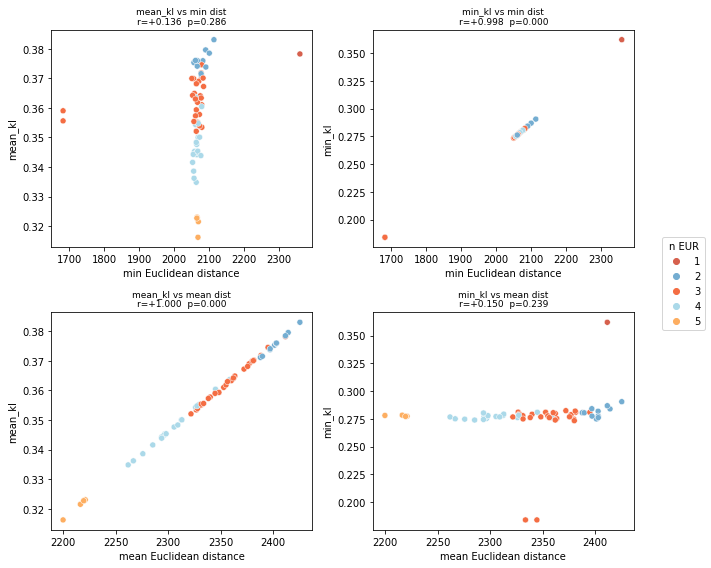

In [19]:
### scatter: expected KL vs Euclidean genetic distance
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
pairs_dist = [('mean_kl', 'min'), ('min_kl', 'min'),
              ('mean_kl', 'mean'), ('min_kl', 'mean')]
for ax, (kc, dc) in zip(axes.flat, pairs_dist):
    sub = plot_df[[kc, dc, 'n_eur']].dropna().reset_index()
    r, p = pearsonr(sub[kc], sub[dc])
    sns.scatterplot(data=sub, x=dc, y=kc, hue='n_eur', palette=pal, ax=ax)
    ax.set_title(f'{kc} vs {dc} dist\nr={r:+.3f}  p={p:.3f}', fontsize=9)
    ax.set_xlabel(f'{dc} Euclidean distance')
    ax.set_ylabel(kc)
    ax.get_legend().remove()

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title='n EUR', bbox_to_anchor=(1.02, 0.5), loc='center left')
plt.tight_layout()
fig.savefig(f'{figdir}/01a_expected_kl_vs_euclidean.pdf', bbox_inches='tight')

In [20]:
!date

Thu Jun 11 15:28:25 PDT 2026
